In [8]:
# =========================================================
# 1. IMPORTAR LIBRERÍAS
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [9]:
# =========================================================
# 2. CARGAR DATASET Y DEFINIR VARIABLES
# =========================================================

# Cargar dataset preprocesado
df = pd.read_csv("natalidad_preprocesado_ucin.csv")

# Variable objetivo
target = "ucin"

# Variables predictoras y target
X = df.drop(columns=[target])
y = df[target]

print("Dimensiones del dataset:", df.shape)
print("Número de variables predictoras:", X.shape[1])

print("\nDistribución del target (%):")
print((y.value_counts(normalize=True) * 100).round(2))

Dimensiones del dataset: (3668913, 69)
Número de variables predictoras: 68

Distribución del target (%):
ucin
0    90.51
1     9.49
Name: proportion, dtype: float64


In [10]:
# =========================================================
# 3. DIVISIÓN ENTRENAMIENTO / PRUEBA
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)

print("\nDistribución y_train (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución y_test (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))

Tamaño X_train: (2935130, 68)
Tamaño X_test: (733783, 68)

Distribución y_train (%):
ucin
0    90.51
1     9.49
Name: proportion, dtype: float64

Distribución y_test (%):
ucin
0    90.51
1     9.49
Name: proportion, dtype: float64


In [11]:
# =========================================================
# 4. CREAR MODELO REGRESIÓN LOGÍSTICA
# =========================================================

pipeline_lr_final = Pipeline([

    # Estandarización de variables
    ("scaler", StandardScaler()),

    # Modelo de regresión logística
    ("model", LogisticRegression(

        C=0.01,                 # fuerza de regularización
        penalty="l1",           # regularización L1

        solver="saga",          # optimizador compatible con L1

        class_weight="balanced", # balanceo automático de clases

        max_iter=3000,          # máximo de iteraciones

        random_state=42,
        n_jobs=-1

    ))
])

In [12]:
# =========================================================
# 5. ENTRENAR MODELO
# =========================================================

pipeline_lr_final.fit(X_train, y_train)

c:\MIS_PROYECTOS\finalmaster2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\MIS_PROYECTOS\finalmaster2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\MIS_PROYECTOS\finalmaster2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with

In [13]:
# =========================================================
# 8. BÚSQUEDA DEL MEJOR UMBRAL SEGÚN RECALL OBJETIVO
# =========================================================

import numpy as np
import pandas as pd

# Recall clínico objetivo
recall_objetivo = 0.80

# Probabilidades de clase positiva: UCIN = 1
y_proba = pipeline_lr_final.predict_proba(X_test)[:, 1]

# Probar umbrales entre 0.10 y 0.90
umbrales = np.arange(0.10, 0.91, 0.01)

resultados_umbral = []

for umbral in umbrales:
    y_pred = (y_proba >= umbral).astype(int)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    resultados_umbral.append({
        "umbral": umbral,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "diferencia_recall": abs(recall - recall_objetivo)
    })

# Convertir a DataFrame
df_umbral = pd.DataFrame(resultados_umbral)

# Seleccionar el umbral cuyo recall esté más cerca de 0.80
mejor_umbral = df_umbral.sort_values(
    by=["diferencia_recall", "f1_score"],
    ascending=[True, False]
).iloc[0]

print("================= MEJOR UMBRAL REGRESIÓN LOGÍSTICA =================")
print(f"Recall objetivo : {recall_objetivo:.2f}")
print(f"Umbral elegido  : {mejor_umbral['umbral']:.2f}")
print(f"Accuracy        : {mejor_umbral['accuracy']:.4f}")
print(f"Precision       : {mejor_umbral['precision']:.4f}")
print(f"Recall          : {mejor_umbral['recall']:.4f}")
print(f"F1-score        : {mejor_umbral['f1_score']:.4f}")

# Ver los 10 umbrales más cercanos al recall objetivo
print("\nTop 10 umbrales más cercanos al recall objetivo:")
print(df_umbral.sort_values(by="diferencia_recall").head(10))

================= MEJOR UMBRAL REGRESIÓN LOGÍSTICA =================
Recall objetivo : 0.80
Umbral elegido  : 0.43
Accuracy        : 0.8333
Precision       : 0.3391
Recall          : 0.7976
F1-score        : 0.4758

Top 10 umbrales más cercanos al recall objetivo:
    umbral  accuracy  precision    recall  f1_score  diferencia_recall
33    0.43  0.833260   0.339064  0.797602  0.475844           0.002398
32    0.42  0.826548   0.329927  0.803016  0.467696           0.003016
34    0.44  0.839448   0.348011  0.792173  0.483579           0.007827
31    0.41  0.819652   0.321234  0.809134  0.459888           0.009134
35    0.45  0.845272   0.356998  0.787103  0.491205           0.012897
30    0.40  0.812356   0.312528  0.814735  0.451762           0.014735
36    0.46  0.850892   0.366196  0.781833  0.498775           0.018167
29    0.39  0.804427   0.303549  0.819719  0.443038           0.019719
37    0.47  0.855923   0.374902  0.776677  0.505702           0.023323
28    0.38  0.795919   0.

In [16]:
# =========================================================
# 6. PREDICCIONES
# =========================================================

# Probabilidad de ingreso en UCIN
y_proba = pipeline_lr_final.predict_proba(X_test)[:, 1]

# Umbral de clasificación
umbral = 0.38

# Convertir probabilidades en clases
y_pred = (y_proba >= umbral).astype(int)


================= MÉTRICAS REGRESIÓN LOGÍSTICA =================
Umbral   : 0.38
Accuracy : 0.7959
Precision: 0.2946
Recall   : 0.8249
F1-score : 0.4341
AUC-ROC  : 0.8812

================= CLASSIFICATION REPORT =================
              precision    recall  f1-score   support

           0     0.9774    0.7929    0.8755    664153
           1     0.2946    0.8249    0.4341     69630

    accuracy                         0.7959    733783
   macro avg     0.6360    0.8089    0.6548    733783
weighted avg     0.9126    0.7959    0.8336    733783



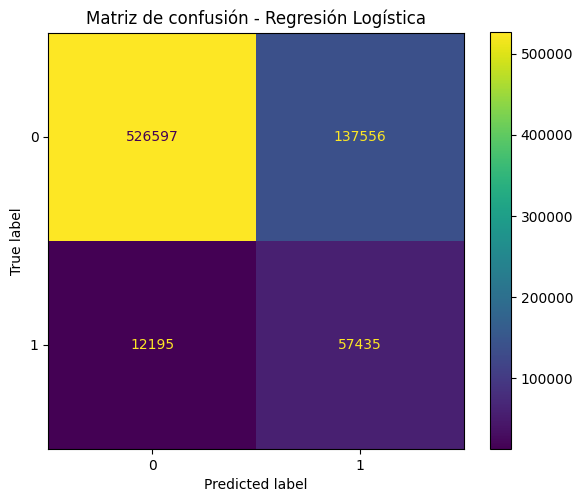

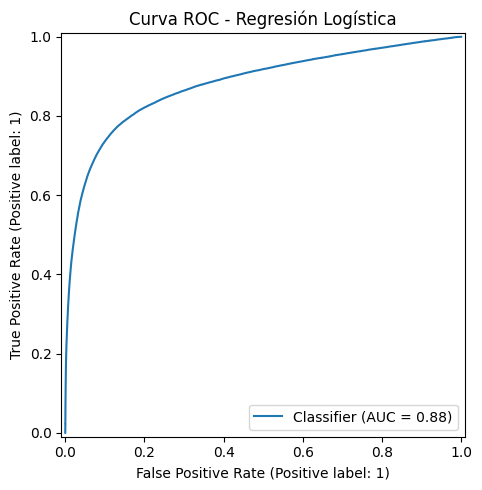


================= VARIABLES CON MAYOR EFECTO POSITIVO =================
    Variable  Coeficiente
56  ab_aven1     0.478985
57  ab_aven6     0.379933
43   me_rout     0.327046
38   ld_ster     0.253543
40   ld_chor     0.176778
23  rf_pdiab     0.111325
61   ca_cchd     0.099315
21       bmi     0.098593
22    wtgain     0.078580
58   ab_seiz     0.073659
49     mtran     0.071133
24  rf_gdiab     0.067599
32   ip_syph     0.067202
35   ip_hepc     0.064521
41   ld_anes     0.060233

================= VARIABLES CON MAYOR EFECTO NEGATIVO =================
     Variable  Coeficiente
36    ob_ecvs    -0.005561
1      dob_tt    -0.010447
50        pay    -0.014322
37    ld_augm    -0.015131
8     mrace15    -0.016666
13  priorlive    -0.021415
11      meduc    -0.037308
16    precare    -0.044515
30   rf_cesar    -0.060073
48     attend    -0.065751
3      bfacil    -0.109320
17     previs    -0.130038
54   combgest    -0.424122
51     apgar5    -0.468404
55       dbwt    -0.498001

Ejemp

In [17]:
# =========================================================
# 7. MÉTRICAS
# =========================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("\n================= MÉTRICAS REGRESIÓN LOGÍSTICA =================")
print(f"Umbral   : {umbral:.2f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")

print("\n================= CLASSIFICATION REPORT =================")
print(classification_report(y_test, y_pred, digits=4))


# =========================================================
# 8. MATRIZ DE CONFUSIÓN
# =========================================================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(values_format="d", ax=ax)
ax.set_title("Matriz de confusión - Regresión Logística")
plt.tight_layout()
plt.show()


# =========================================================
# 9. CURVA ROC
# =========================================================

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax)
ax.set_title("Curva ROC - Regresión Logística")
plt.tight_layout()
plt.show()


# =========================================================
# 10. COEFICIENTES DEL MODELO
# =========================================================

coef = pipeline_lr_final.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": coef
}).sort_values(by="Coeficiente", ascending=False)

print("\n================= VARIABLES CON MAYOR EFECTO POSITIVO =================")
print(coef_df.head(15))

print("\n================= VARIABLES CON MAYOR EFECTO NEGATIVO =================")
print(coef_df.tail(15))

coef_df.to_csv("coeficientes_regresion_logistica.csv", index=False)


# =========================================================
# 11. GUARDAR PREDICCIONES
# =========================================================

resultados = X_test.copy()

resultados["y_real"] = y_test.values
resultados["y_pred"] = y_pred
resultados["prob_ucin"] = y_proba

print("\nEjemplo de predicciones:")
print(resultados.head())

resultados.to_csv("predicciones_regresion_logistica.csv", index=False)